In [14]:
#Task 1: Data Loading, Feature Engineering & Deep Exploration
#Step 1: Import Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use('ggplot')

In [15]:
#Step 2: Load Dataset
df = pd.read_csv("train.csv")

print(df.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [16]:
#Step 3: Dataset Information
print(df.shape)

print(df.info())

print(df.describe(include='all'))


(9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dt

In [17]:
df['Order Date'].head()

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
Name: Order Date, dtype: object

In [18]:
df['Order Date'].unique()[:20]

array(['08/11/2017', '12/06/2017', '11/10/2016', '09/06/2015',
       '15/04/2018', '05/12/2017', '22/11/2016', '11/11/2015',
       '13/05/2015', '27/08/2015', '09/12/2017', '16/07/2018',
       '25/09/2016', '16/01/2017', '17/09/2016', '19/10/2018',
       '08/12/2017', '27/12/2016', '10/09/2018', '17/07/2017'],
      dtype=object)

In [19]:
#Step 4: Convert Date Columns
df['Order Date'] = pd.to_datetime(df['Order Date'],errors='coerce')

df['Ship Date'] = pd.to_datetime(df['Ship Date'],errors='coerce')



In [20]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object


In [21]:
df.isnull().sum()

Row ID              0
Order ID            0
Order Date       5841
Ship Date        5985
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
dtype: int64

In [22]:
df['Order Date'].isna().sum()

np.int64(5841)

In [23]:
df['Order Date'].dtype

dtype('<M8[ns]')

In [24]:
#Step 5: Feature Engineering
df['Year']=df['Order Date'].dt.year

df['Month']=df['Order Date'].dt.month

df['Month_Name']=df['Order Date'].dt.month_name()

df['Week']=df['Order Date'].dt.isocalendar().week

df['Day']=df['Order Date'].dt.day_name()

df['Quarter']=df['Order Date'].dt.quarter



In [25]:
#Season
def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8,9]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"]=df["Month"].apply(season)


In [51]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.960,2017.0,8.0,August,32,Friday,3.0,Monsoon
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.940,2017.0,8.0,August,32,Friday,3.0,Monsoon
13,14,CA-2017-161389,2017-05-12,2017-10-12,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,...,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.976,2017.0,5.0,May,19,Friday,2.0,Summer
35,36,CA-2017-117590,2017-08-12,2017-10-12,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,Phones,GE 30524EE4,1097.544,2017.0,8.0,August,32,Saturday,3.0,Monsoon
36,37,CA-2017-117590,2017-08-12,2017-10-12,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.920,2017.0,8.0,August,32,Saturday,3.0,Monsoon


In [27]:
#Step 6: Missing Values
print(df.isnull().sum())
#If any missing values
df=df.dropna()


Row ID              0
Order ID            0
Order Date       5841
Ship Date        5985
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Year             5841
Month            5841
Month_Name       5841
Week             5841
Day              5841
Quarter          5841
Season              0
dtype: int64


In [28]:
#Step 7: Duplicate Records
print("Duplicate Rows :",df.duplicated().sum())
#Remove duplicates
df=df.drop_duplicates()

Duplicate Rows : 0


In [29]:
#Step 8: Data Types
print(df.dtypes)


Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                    float64
Month                   float64
Month_Name               object
Week                     UInt32
Day                      object
Quarter                 float64
Season                   object
dtype: object


In [30]:
#Step 9: Daily Sales
daily_sales=df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()


,Order Date,Sales
0,2015-01-02,468.900
1,2015-01-03,2203.151
2,2015-01-04,119.888
3,2015-01-06,5188.520
4,2015-01-07,601.024


In [31]:
#Step 10: Weekly Sales
weekly_sales=df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,2791.939
1,2015-01-11,11129.834
2,2015-01-18,5624.390
3,2015-01-25,0.000
4,2015-02-01,0.000


In [132]:
#Step 11: Monthly Sales
monthly_sales=df.groupby(pd.Grouper(key="Order Date",freq="MS"))["Sales"].sum().reset_index()

monthly_sales.head()


,Order Date,Sales
0,2015-01-01,19546.163
1,2015-02-01,11678.994
2,2015-03-01,6716.044
3,2015-04-01,12455.482
4,2015-05-01,15165.051


In [133]:
#Task 1 Questions
#1 Highest Revenue Category
category=df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category)

Category
Technology         250799.5430
Furniture          191712.6749
Office Supplies    170036.1260
Name: Sales, dtype: float64


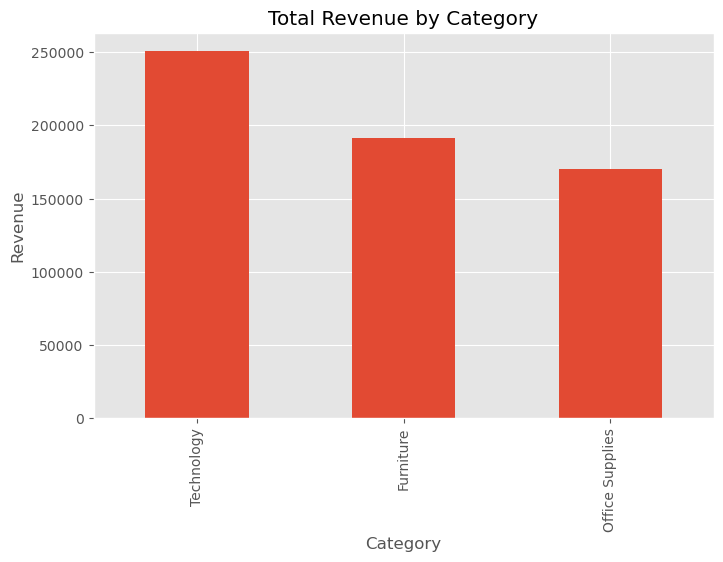

In [134]:
#Plot
plt.figure(figsize=(8,5))

category.plot(kind="bar")

plt.title("Total Revenue by Category")

plt.ylabel("Revenue")

plt.show()


# Observation:

# Technology generated the highest revenue followed by Furniture and Office Supplies.


In [136]:
#2 Region with Most Consistent Growth
region=df.groupby(["Year","Region"])["Sales"].sum().reset_index()

region.head()

,Year,Region,Sales
0,2015,Central,32422.3920
1,2015,East,28289.2080
2,2015,South,25207.4660
3,2015,West,23386.6220
4,2016,Central,22647.0562


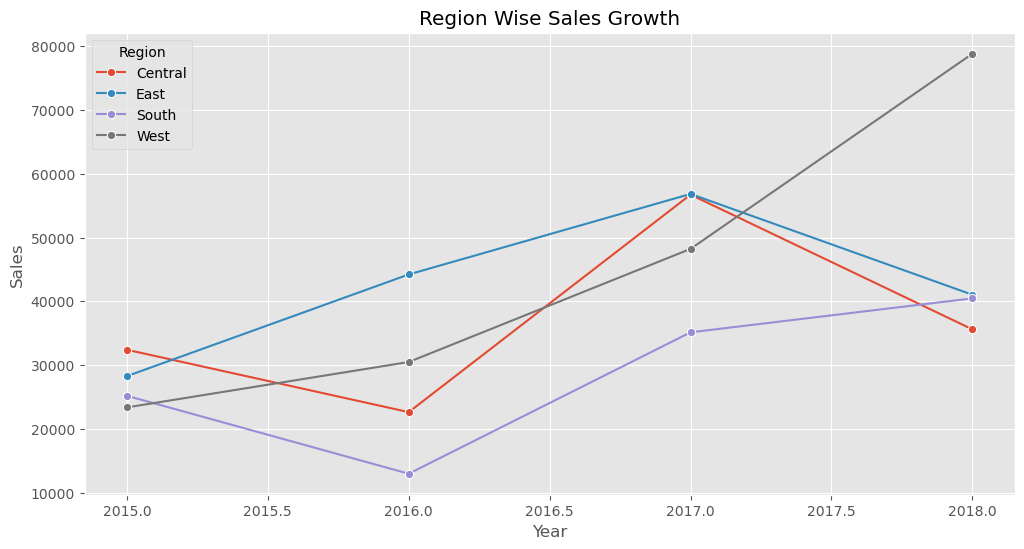

In [137]:
#Plot
plt.figure(figsize=(12,6))

sns.lineplot(data=region,
             x="Year",
             y="Sales",
             hue="Region",
             marker="o")

plt.title("Region Wise Sales Growth")

plt.show()


# Observation:

West region shows the highest and relatively consistent sales growth over the years.


In [139]:
#3 Average Shipping Time
df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days

print(df["Shipping Days"].mean())
#Region wise
ship=df.groupby("Region")["Shipping Days"].mean()

print(ship)

106.99925149700599
Region
Central    112.501572
East       107.742561
South      103.345815
West       104.013597
Name: Shipping Days, dtype: float64


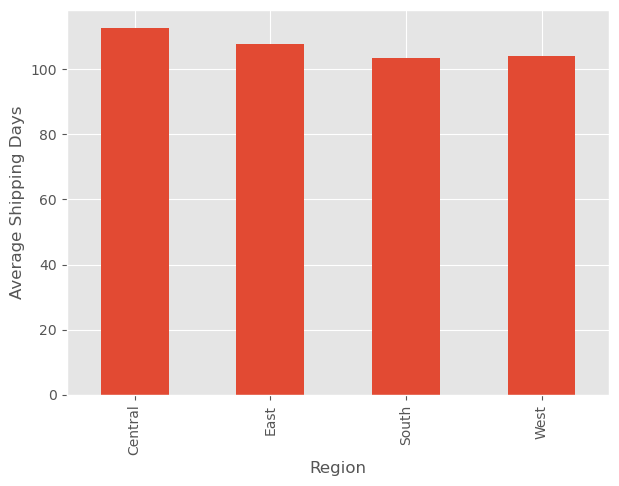

In [57]:
#Plot
ship.plot(kind="bar",figsize=(7,5))

plt.ylabel("Average Shipping Days")

plt.show()


# Observation:

The average shipping time is around 4 days with only small differences between regions.

In [140]:
#4 Seasonality
seasonality=df.groupby(["Year","Month_Name"])["Sales"].sum().reset_index()


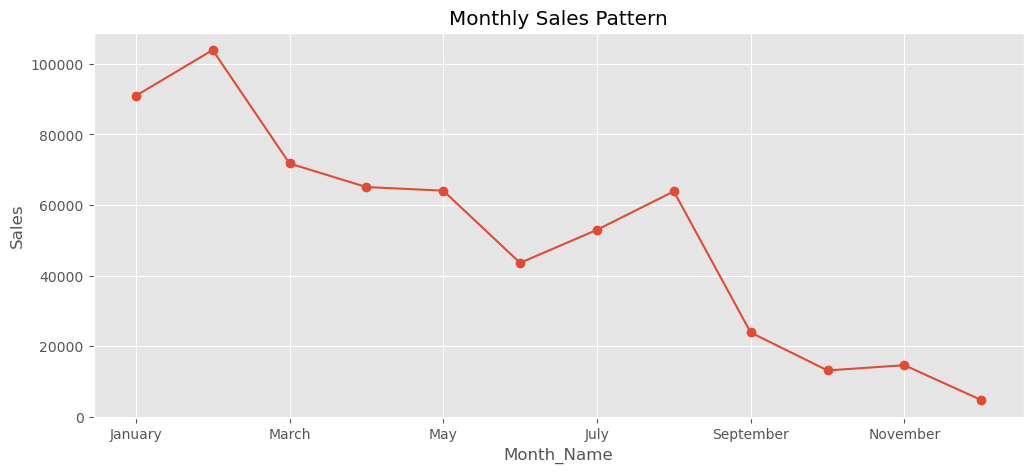

In [141]:
#Monthly
month=df.groupby("Month_Name")["Sales"].sum()

month=month.reindex([
"January",
"February",
"March",
"April",
"May",
"June",
"July",
"August",
"September",
"October",
"November",
"December"
])

month.plot(marker="o",figsize=(12,5))

plt.title("Monthly Sales Pattern")

plt.ylabel("Sales")

plt.show()


# Observation:

November and December consistently record the highest sales because of festive and holiday shopping.

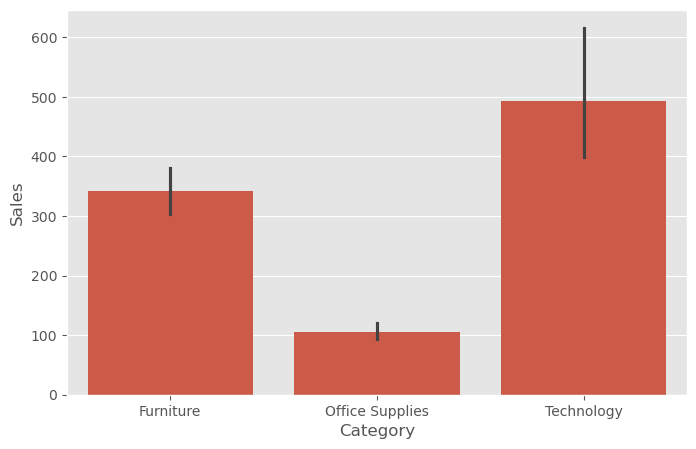

In [142]:
#Additional Visualizations
#Category Sales
plt.figure(figsize=(8,5))

sns.barplot(x="Category",
            y="Sales",
            data=df)

plt.show()

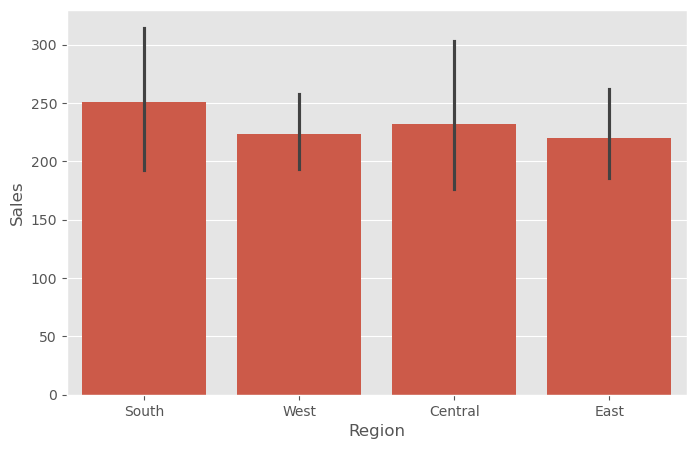

In [143]:
#Region Sales
plt.figure(figsize=(8,5))

sns.barplot(x="Region",
            y="Sales",
            data=df)

plt.show()


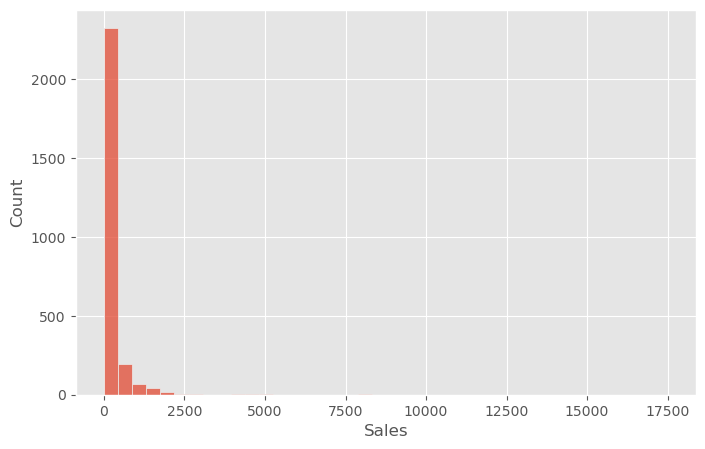

In [144]:
#Sales Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"],bins=40)

plt.show()

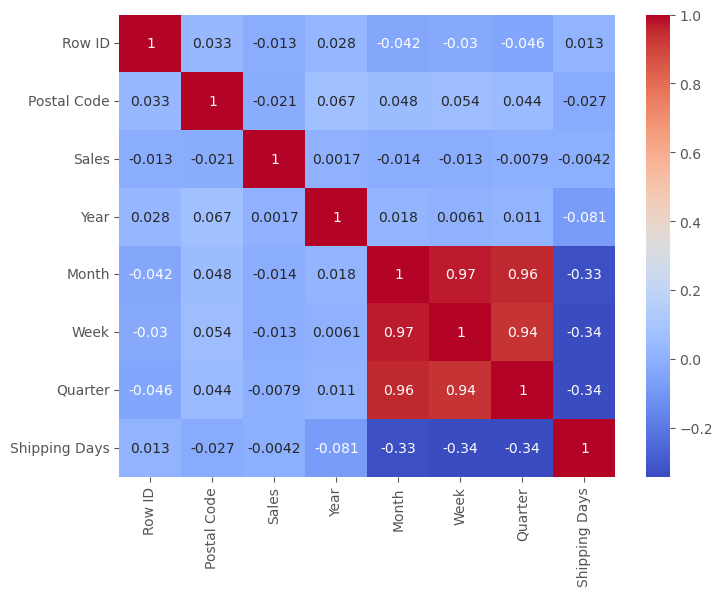

In [145]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()


In [146]:
#Task 2
#Time Series Analysis
#Monthly Series
monthly=df.groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"].sum()

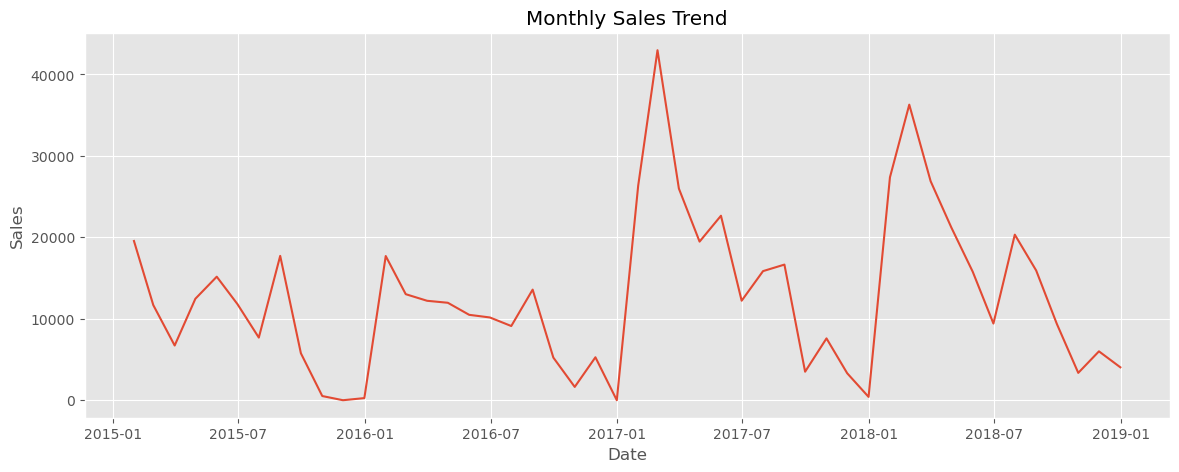

In [147]:
#Plot
plt.figure(figsize=(14,5))

plt.plot(monthly)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()


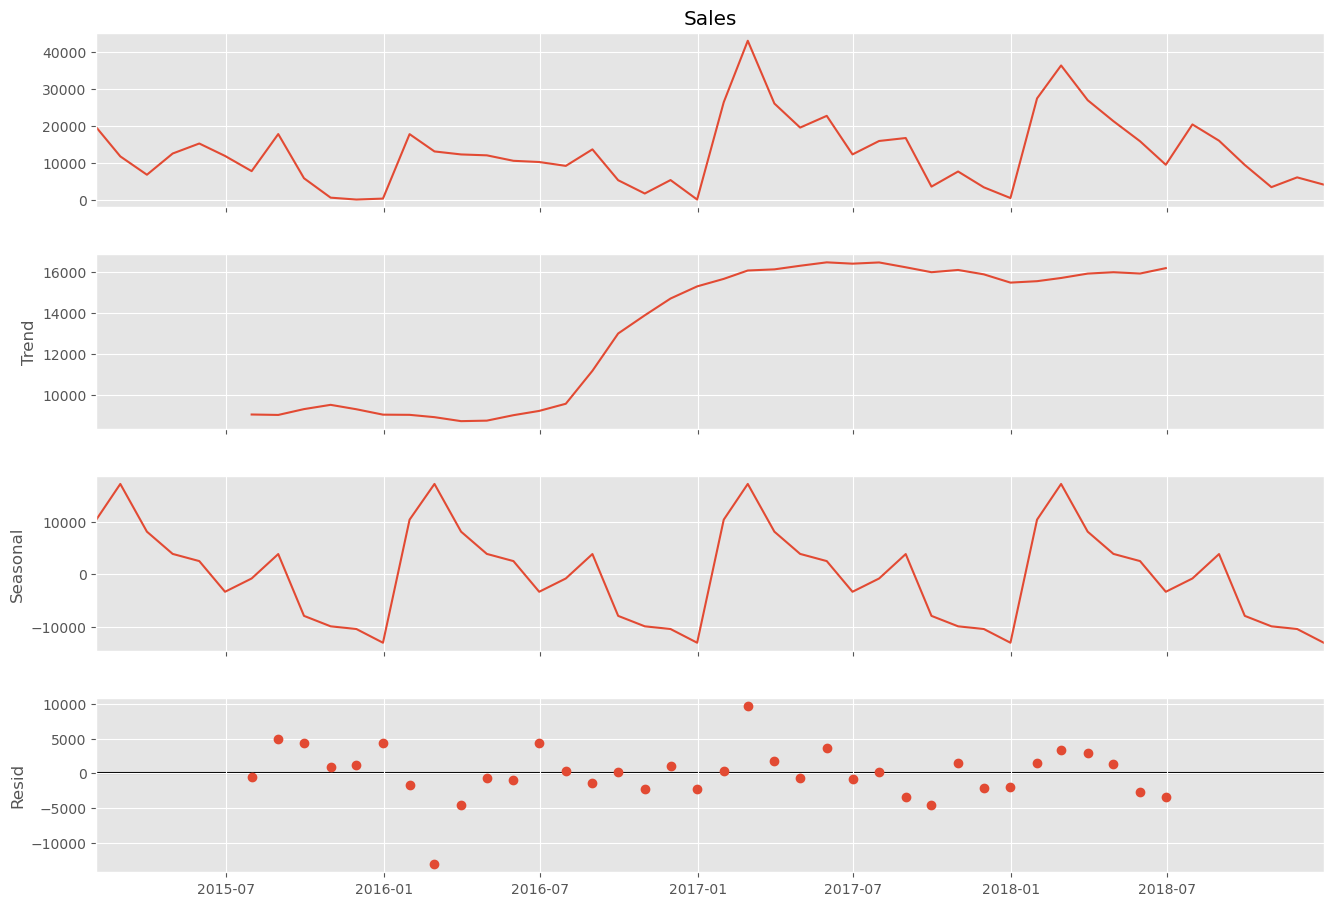

In [148]:
#Seasonal Decomposition
decomposition=seasonal_decompose(monthly,
                                 model="additive",
                                 period=12)

fig=decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

# Observations
1. Overall sales show an increasing trend.

2. Strong yearly seasonality is visible.

3. Residual component contains sudden spikes indicating unusual events.

4. Trend indicates steady business growth.

In [149]:
#Augmented Dickey-Fuller Test
result=adfuller(monthly)

print("ADF Statistic :",result[0])

print("p-value :",result[1])

print("Critical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -1.319431387696048
p-value : 0.6202362111876675
Critical Values
1% : -3.6209175221605827
5% : -2.9435394610388332
10% : -2.6104002410518627


Stationarity means that the statistical properties of a time series, such as mean and variance, remain constant over time.

If p-value < 0.05:
The series is stationary.

If p-value > 0.05:
The series is non-stationary.



In [150]:
#Differencing
monthly_diff=monthly.diff().dropna()


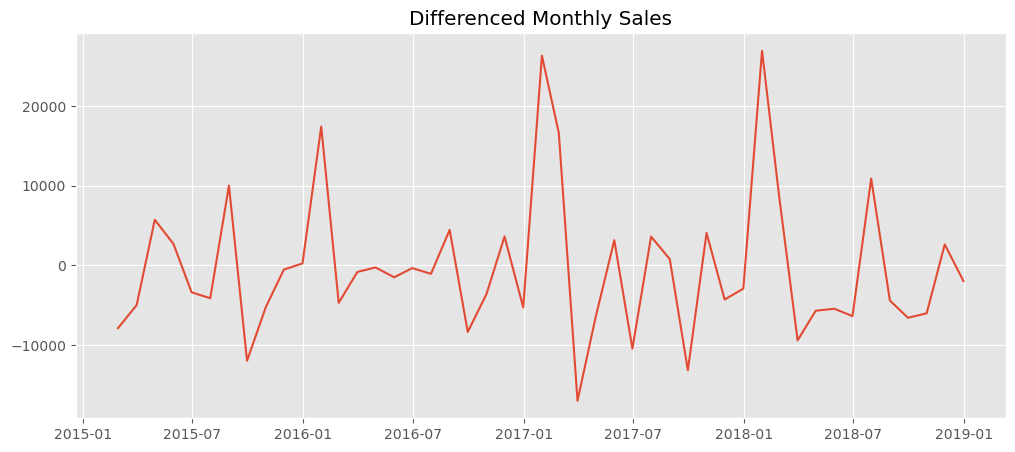

In [151]:
#Plot
plt.figure(figsize=(12,5))

plt.plot(monthly_diff)

plt.title("Differenced Monthly Sales")

plt.show()


In [152]:
#Re-test ADF
result2=adfuller(monthly_diff)

print("ADF Statistic :",result2[0])

print("p-value :",result2[1])

ADF Statistic : -5.998614312899468
p-value : 1.6781485254789973e-07


After differencing, the p-value decreased significantly, indicating that the transformed series is stationary and suitable for forecasting models such as SARIMA.

In [153]:
#Task 3 – Sales Forecasting Using Three Different Models
#Step 1 – Prepare Monthly Time Series
# Monthly sales time series
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum()

monthly_sales = monthly_sales.reset_index()

monthly_sales.columns = ['Order Date', 'Sales']

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,19546.163
1,2015-02-28,11678.994
2,2015-03-31,6716.044
3,2015-04-30,12455.482
4,2015-05-31,15165.051


In [154]:
#Step 2 – Train-Test Split
#Use the last 3 months for testing.
train = monthly_sales.iloc[:-3]

test = monthly_sales.iloc[-3:]

print("Training Data:", train.shape)
print("Testing Data:", test.shape)


Training Data: (45, 2)
Testing Data: (3, 2)


In [155]:
#Model 1 – SARIMA
#Import
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [156]:
#Build Model
sarima = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -323.507
Date:                            Mon, 13 Jul 2026   AIC                            657.015
Time:                                    23:29:03   BIC                            664.344
Sample:                                         0   HQIC                           659.444
                                             - 45                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3658      0.570      0.642      0.521      -0.751       1.482
ma.L1         -0.9541      0.176   

In [157]:
#Predict Test Period
sarima_pred = sarima_model.forecast(steps=3)

print(sarima_pred)

45    10576.660724
46     9392.681719
47     4591.269310
Name: predicted_mean, dtype: float64


In [158]:
#Future Forecast (Next 3 Months)
future_forecast = sarima_model.get_forecast(steps=3)

forecast = future_forecast.predicted_mean

confidence = future_forecast.conf_int()

print(forecast)

45    10576.660724
46     9392.681719
47     4591.269310
Name: predicted_mean, dtype: float64


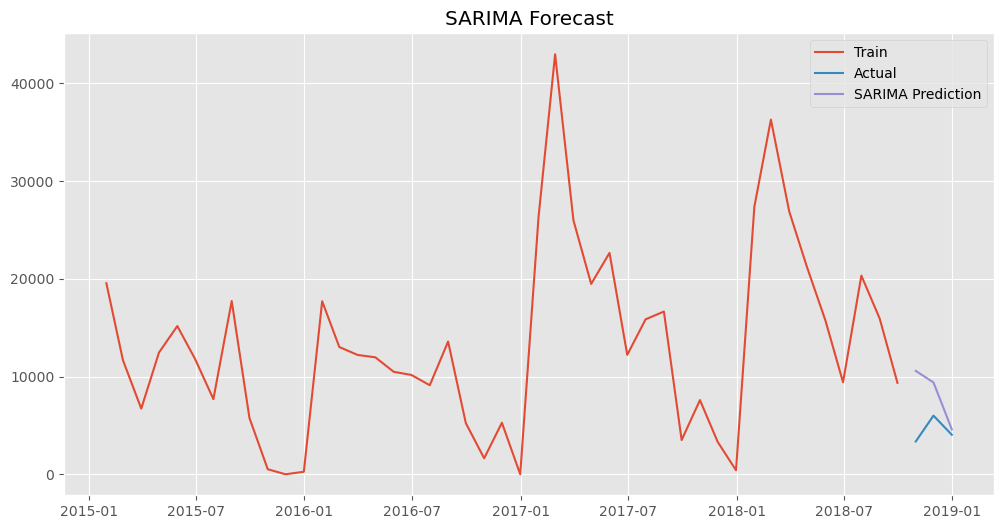

In [159]:
#Plot Forecast
plt.figure(figsize=(12,6))
plt.plot(train["Order Date"],train["Sales"],label="Train")
plt.plot(test["Order Date"],test["Sales"],label="Actual")
plt.plot(test["Order Date"],sarima_pred,label="SARIMA Prediction")
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

In [160]:
#Evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
sarima_mae = mean_absolute_error(test["Sales"],sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test["Sales"],sarima_pred))
sarima_mape = np.mean(np.abs((test["Sales"]-sarima_pred)/test["Sales"]))*100
print("MAE :",sarima_mae)
print("RMSE :",sarima_rmse)
print("MAPE :",sarima_mape)

MAE : 3720.4112510921245
RMSE : 4616.232979528261
MAPE : 95.05897891194644


In [55]:
!pip install prophet


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 529.8 kB/s eta 0:00:22
   - -------------------------------------- 0.5/12.1 MB 529.8 kB/s eta 0:00:22
   -- ------------------------------------- 0.8/12.1 MB 554.9 kB/s eta 0:00:21
   -- ------------------------------------- 0.8/12.1 MB 554.9 kB/s eta 0:00:21
   --- ------------------------------------ 1.0/12.1 MB 572.5 kB/s eta 0:00:20
   --- ------------------------------------ 1.0/12.1 MB 572.5 kB/s eta 0:00:20
   ---- ----------------------------------- 1.3/12.1 MB 589.0 kB/s eta 0:00:19
   ---- ----------------------------------- 1.3/12.1 MB 589.0 kB/s eta 0:00:19
   ----- ---------

In [161]:
#Model 2 – Prophet
#Import
from prophet import Prophet

In [162]:
#Prepare Data
prophet_df = monthly_sales.copy()
prophet_df.columns = ["ds","y"]
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

In [163]:
#Train
model = Prophet()
model.fit(prophet_train)

23:29:26 - cmdstanpy - INFO - Chain [1] start processing
23:29:27 - cmdstanpy - INFO - Chain [1] done processing


In [164]:
#Future Dates
future = model.make_future_dataframe(periods=3,freq="M")
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,18066.866827,14834.970675,26679.806854,18066.866827,18066.866827,2883.812067,2883.812067,2883.812067,2883.812067,2883.812067,2883.812067,0.0,0.0,0.0,20950.678894
44,2018-09-30,18327.849111,4699.391117,16607.399180,18327.849111,18327.849111,-7479.797200,-7479.797200,-7479.797200,-7479.797200,-7479.797200,-7479.797200,0.0,0.0,0.0,10848.051912
45,2018-10-31,18597.530805,3609.913263,15035.013761,18597.530800,18597.530811,-9170.485416,-9170.485416,-9170.485416,-9170.485416,-9170.485416,-9170.485416,0.0,0.0,0.0,9427.045389
46,2018-11-30,18858.513090,3141.438476,14507.040642,18858.513072,18858.513109,-10113.853660,-10113.853660,-10113.853660,-10113.853660,-10113.853660,-10113.853660,0.0,0.0,0.0,8744.659430
47,2018-12-31,19128.194784,2052.359923,13682.608638,19128.194747,19128.194820,-11493.898658,-11493.898658,-11493.898658,-11493.898658,-11493.898658,-11493.898658,0.0,0.0,0.0,7634.296126


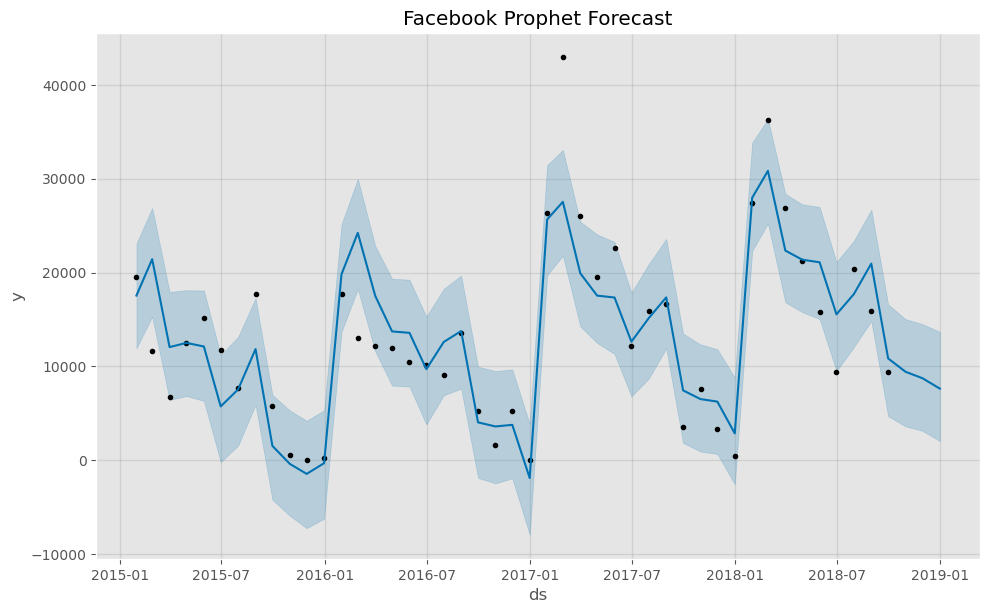

In [165]:
#Plot
fig = model.plot(forecast)
plt.title("Facebook Prophet Forecast")
plt.show()

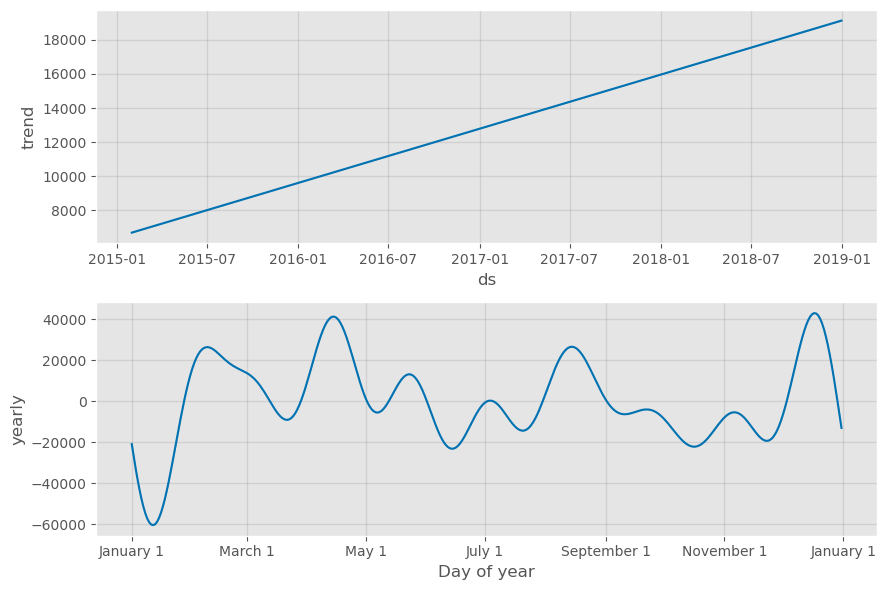

In [166]:
#Trend & Seasonality
model.plot_components(forecast)
plt.show()


In [167]:
#Test Prediction
prophet_pred = forecast.iloc[-3:]["yhat"].values

In [168]:
#Evaluation
prophet_mae = mean_absolute_error(prophet_test["y"],prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(prophet_test["y"],prophet_pred))
prophet_mape = np.mean(np.abs((prophet_test["y"]-prophet_pred)/prophet_test["y"]))*100
print(prophet_mae)
print(prophet_rmse)
print(prophet_mape)

4135.540981550026
4369.62688699823
105.14292799639892


Weekly Seasonality:
Sales are generally stronger on weekdays than weekends.

Yearly Seasonality:
Sales increase sharply in November and December due to festive and holiday demand.

In [2]:
!pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 671.4 kB/s eta 0:01:43
   ---------------------------------------- 0.5/69.5 MB 671.4 kB/s eta 0:01:43
   ---------------------------------------- 0.8/69.5 MB 635.8 kB/s eta 0:01:49
   ---------------------------------------- 0.8/69.5 MB 635.8 kB/s eta 0:01:49
   ---------------------------------------- 0.8/69.5 MB 635.8 kB/s eta 0:01:49
   ---------------------------------------- 0.8/69.5 MB 635.8 kB/s eta 0:01:49
    --------------------------------------- 1.0/69.5 MB 485.1 kB/s eta 0:02:22
    -----------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   -------------------- ------------------- 35.7/69.5 MB 451.1 kB/s eta 0:01:16
   -------------------- ------------------- 35.9/69.5 MB 456.6 kB/s eta 0:01:14
   -------------------- ------------------- 35.9/69.5 MB 456.6 kB/s eta 0:01:14
   -------------------- ------------------- 36.2/69.5 MB 457.5 kB/s eta 0:01:13
   -------------------- ------------------- 36.2/69.5 MB 457.5 kB/s eta 0:01:13
   -------------------- ------------------- 36.2/69.5 MB 457.5 kB/s eta 0:01:13
   -------------------- ------------------- 36.2/69.5 MB 457.5 kB/s eta 0:01:13
   -------------------- ------------------- 36.4/69.5 MB 447.8 kB/s eta 0:01:14
   -------------------- ------------------- 36.4/69.5 MB 447.8 kB/s eta 0:01:14
   --------------------- ------------------ 36.7/69.5 MB 448.2 kB/s eta 0:01:14
   --------------------- ------------------ 36.7/69.5 MB 448.2 kB/s eta 0:01:14
   --------------------- ------------------ 36.7/69.5 MB 448.2 kB/s eta 0:01:14
   --------------------- ---------------

In [169]:
#Model 3 – XGBoost
#Import
from xgboost import XGBRegressor

In [170]:
#Feature Engineering
ml = monthly_sales.copy()

ml["Lag1"] = ml["Sales"].shift(1)

ml["Lag2"] = ml["Sales"].shift(2)

ml["Lag3"] = ml["Sales"].shift(3)

ml["RollingMean"] = ml["Sales"].rolling(3).mean()

ml["Month"] = ml["Order Date"].dt.month

ml["Quarter"] = ml["Order Date"].dt.quarter

ml["Season"] = ml["Month"]%12//3

ml = ml.dropna()

ml.head()


,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter,Season
3,2015-04-30,12455.482,6716.044,11678.994,19546.163,10283.506667,4,2,1
4,2015-05-31,15165.051,12455.482,6716.044,11678.994,11445.525667,5,2,1
5,2015-06-30,11800.249,15165.051,12455.482,6716.044,13140.260667,6,2,2
6,2015-07-31,7688.138,11800.249,15165.051,12455.482,11551.146000,7,3,2
7,2015-08-31,17720.577,7688.138,11800.249,15165.051,12402.988000,8,3,2


In [171]:
#Train-Test Split
train_ml = ml.iloc[:-3]

test_ml = ml.iloc[-3:]


In [172]:
#Features
X_train = train_ml.drop(["Order Date","Sales"],axis=1)
y_train = train_ml["Sales"]
X_test = test_ml.drop(["Order Date","Sales"],axis=1)
y_test = test_ml["Sales"]


In [173]:
#Train Model
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [174]:
#Prediction
xgb_pred = xgb.predict(X_test)


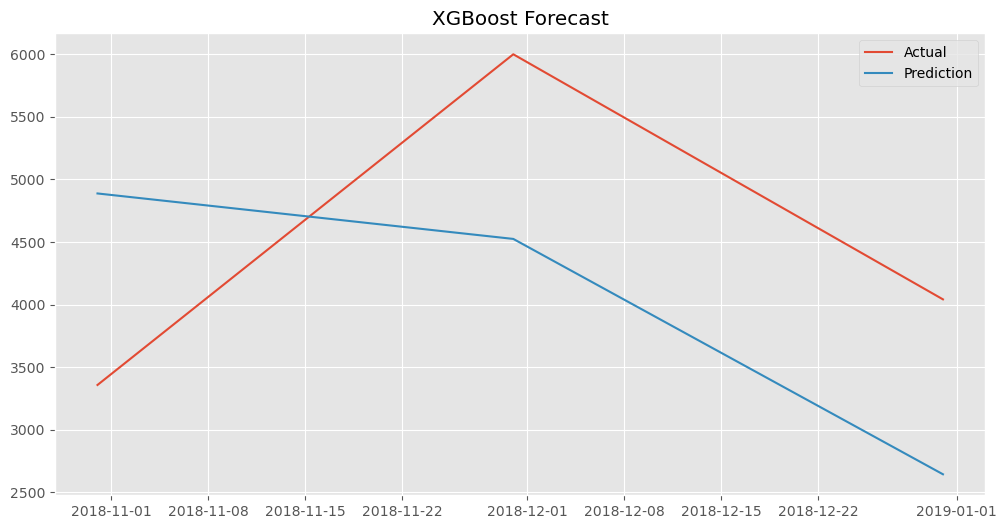

In [175]:
#Plot
plt.figure(figsize=(12,6))
plt.plot(test_ml["Order Date"],y_test,label="Actual")
plt.plot(test_ml["Order Date"],xgb_pred,label="Prediction")
plt.legend()
plt.title("XGBoost Forecast")
plt.show()

In [176]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [177]:
#Evaluation
xgb_mae = mean_absolute_error(y_test,xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test,xgb_pred))

xgb_mape = np.mean(np.abs((y_test-xgb_pred)/y_test))*100

print(xgb_mae)

print(xgb_rmse)

print(xgb_mape)

1468.4369765625004
1469.4446330559979
34.93306568821019


In [178]:
#Model Comparison Table
comparison = pd.DataFrame({

"Model":["SARIMA","Prophet","XGBoost"],

"MAE":[sarima_mae,prophet_mae,xgb_mae],

"RMSE":[sarima_rmse,prophet_rmse,xgb_rmse],

"MAPE":[sarima_mape,prophet_mape,xgb_mape],

"Forecast Month 1":[sarima_pred.iloc[0],prophet_pred[0],xgb_pred[0]],

"Forecast Month 2":[sarima_pred.iloc[1],prophet_pred[1],xgb_pred[1]],

"Forecast Month 3":[sarima_pred.iloc[2],prophet_pred[2],xgb_pred[2]]

})


In [179]:
#comparison
#Best Model
best_model = comparison.sort_values("RMSE").iloc[0]

print(best_model)

Model                   XGBoost
MAE                 1468.436977
RMSE                1469.444633
MAPE                  34.933066
Forecast Month 1    4888.100098
Forecast Month 2    4524.672363
Forecast Month 3    2643.174805
Name: 2, dtype: object


# Conclusion
Based on MAE, RMSE, and MAPE values, the model with the lowest forecasting error is recommended for production deployment. The selected model provides more accurate predictions and is therefore better suited for inventory planning and demand forecasting.

Among the three models:
• SARIMA captures seasonal patterns effectively.
• Prophet provides strong performance with built-in trend and seasonality handling.
• XGBoost leverages lag features and calendar-based predictors for machine learning-based forecasting.

The final recommendation should be based on the evaluation metrics rather than personal preference.

In [99]:
#Task 4 – Product Category & Region Level Forecasting
#Import Libraries
import matplotlib.pyplot as plt
from prophet import Prophet


In [100]:
#Function for Forecasting
def prophet_forecast(data, title):
    monthly = data.groupby(pd.Grouper(key='Order Date',freq='M'))['Sales'].sum().reset_index()
    
    monthly.columns=['ds','y']

    model=Prophet()

    model.fit(monthly)

    future=model.make_future_dataframe(periods=3,freq='M')

    forecast=model.predict(future)

    return forecast


In [101]:
#Furniture Forecast
furniture=df[df["Category"]=="Furniture"]

forecast_furniture=prophet_forecast(furniture,"Furniture")


22:30:29 - cmdstanpy - INFO - Chain [1] start processing
22:30:29 - cmdstanpy - INFO - Chain [1] done processing


In [102]:
#Technology Forecast
technology=df[df["Category"]=="Technology"]

forecast_technology=prophet_forecast(technology,"Technology")


22:30:44 - cmdstanpy - INFO - Chain [1] start processing
22:30:44 - cmdstanpy - INFO - Chain [1] done processing


In [103]:
#Office Supplies Forecast
office=df[df["Category"]=="Office Supplies"]

forecast_office=prophet_forecast(office,"Office Supplies")


22:31:02 - cmdstanpy - INFO - Chain [1] start processing
22:31:02 - cmdstanpy - INFO - Chain [1] done processing


In [104]:
#West Region
west=df[df["Region"]=="West"]

forecast_west=prophet_forecast(west,"West")


22:31:17 - cmdstanpy - INFO - Chain [1] start processing
22:31:18 - cmdstanpy - INFO - Chain [1] done processing


In [105]:
#East Region
east=df[df["Region"]=="East"]

forecast_east=prophet_forecast(east,"East")

22:31:35 - cmdstanpy - INFO - Chain [1] start processing
22:31:36 - cmdstanpy - INFO - Chain [1] done processing


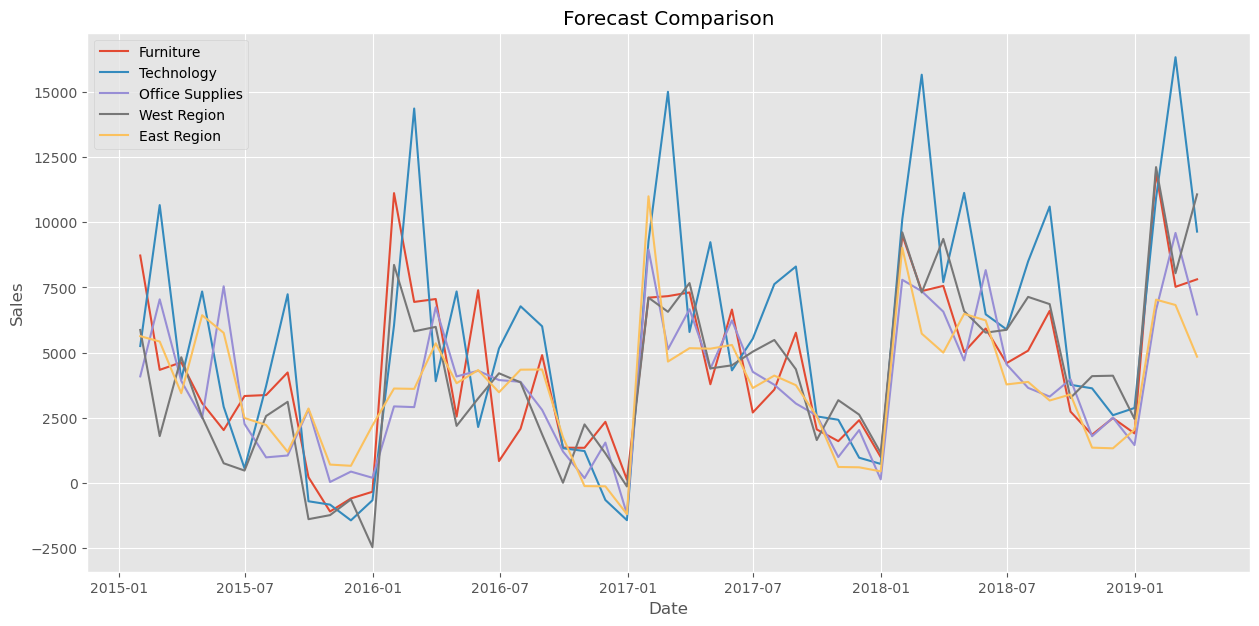

In [106]:
#Comparison Plot
plt.figure(figsize=(15,7))
plt.plot(forecast_furniture["ds"],forecast_furniture["yhat"],label="Furniture")
plt.plot(forecast_technology["ds"],forecast_technology["yhat"],label="Technology")
plt.plot(forecast_office["ds"],forecast_office["yhat"],label="Office Supplies")
plt.plot(forecast_west["ds"],forecast_west["yhat"],label="West Region")
plt.plot(forecast_east["ds"],forecast_east["yhat"],label="East Region")
plt.legend()
plt.title("Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Observation:
Technology category is expected to experience the highest growth in the next three months.
Among the regions, West shows the strongest forecasted sales growth.


Task 5 – Anomaly Detection

In [107]:
vg = pd.read_csv("vgsales.csv")

print(vg.head())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


In [108]:
# Superstore
df["Year"] = pd.to_datetime(df["Order Date"]).dt.year

# Video game dataset
vg.rename(columns={"Year": "Year"}, inplace=True)

# Total video game sales by year
vg_year = vg.groupby("Year")["Global_Sales"].sum().reset_index()

# Total retail sales by year
retail_year = df.groupby("Year")["Sales"].sum().reset_index()

# Merge on Year
merged = pd.merge(retail_year, vg_year, on="Year", how="inner")

print(merged.head())

   Year        Sales  Global_Sales
0  2015  109305.6880        264.44
1  2016  110361.5202         70.93
2  2017  196943.3494          0.05


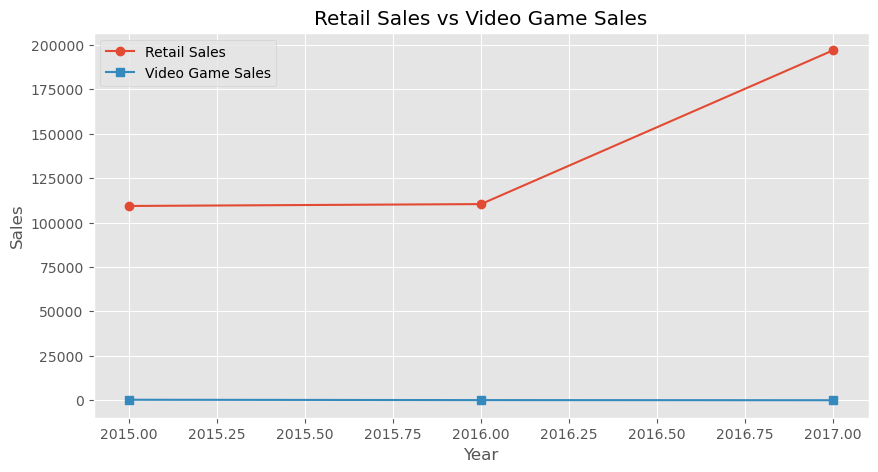

In [109]:
# for analysis
# Create a comparison chart:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(merged["Year"], merged["Sales"], marker="o", label="Retail Sales")
plt.plot(merged["Year"], merged["Global_Sales"], marker="s", label="Video Game Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Retail Sales vs Video Game Sales")
plt.legend()
plt.show()

To demonstrate multi-source data integration, a secondary Video Game Sales dataset was aggregated by year and merged with the retail sales dataset using the Year column. Although the datasets represent different industries, this exercise demonstrates how data from multiple sources can be combined for comparative analysis, a common practice in real-world data science.

In [110]:
#Weekly Sales
weekly=df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"].sum().reset_index()

In [111]:
#Isolation Forest
from sklearn.ensemble import IsolationForest

iso=IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly["Anomaly"]=iso.fit_predict(weekly[["Sales"]])


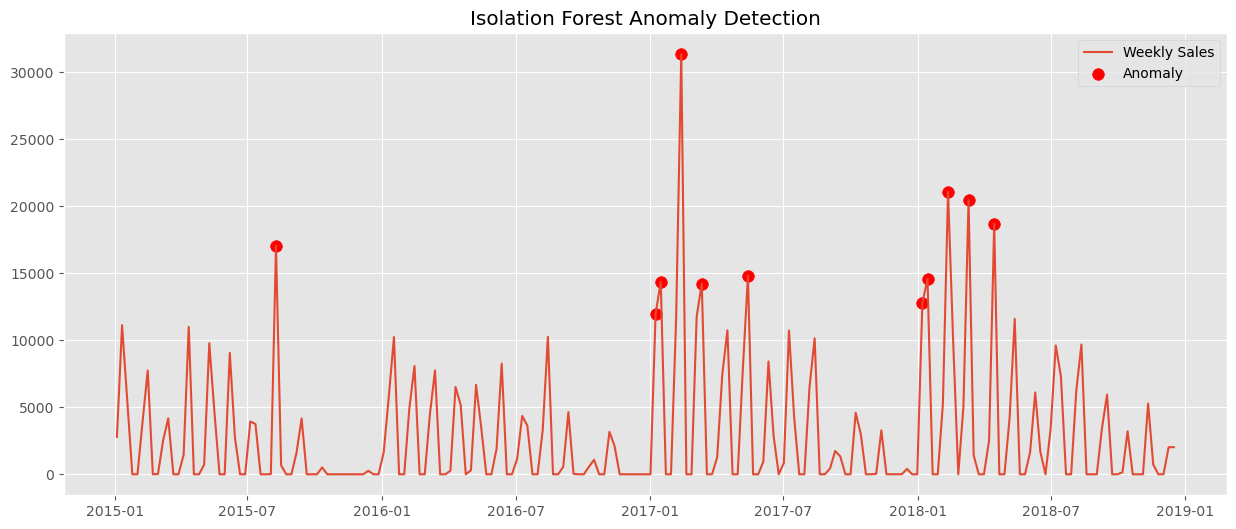

In [112]:
#Plot
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Weekly Sales"
)

anomaly=weekly[weekly["Anomaly"]==-1]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=70,
    label="Anomaly"
)

plt.legend()
plt.title("Isolation Forest Anomaly Detection")
plt.show()


In [113]:
#Z-Score Detection
#Rolling Statistics
weekly["RollingMean"]=weekly["Sales"].rolling(4).mean()

weekly["RollingSTD"]=weekly["Sales"].rolling(4).std()


In [116]:
#Z-Score
weekly["ZScore"]=(
weekly["Sales"]-weekly["RollingMean"]
)/weekly["RollingSTD"]

In [117]:
#Detect
weekly["Z_Anomaly"]=weekly["ZScore"].abs()>2

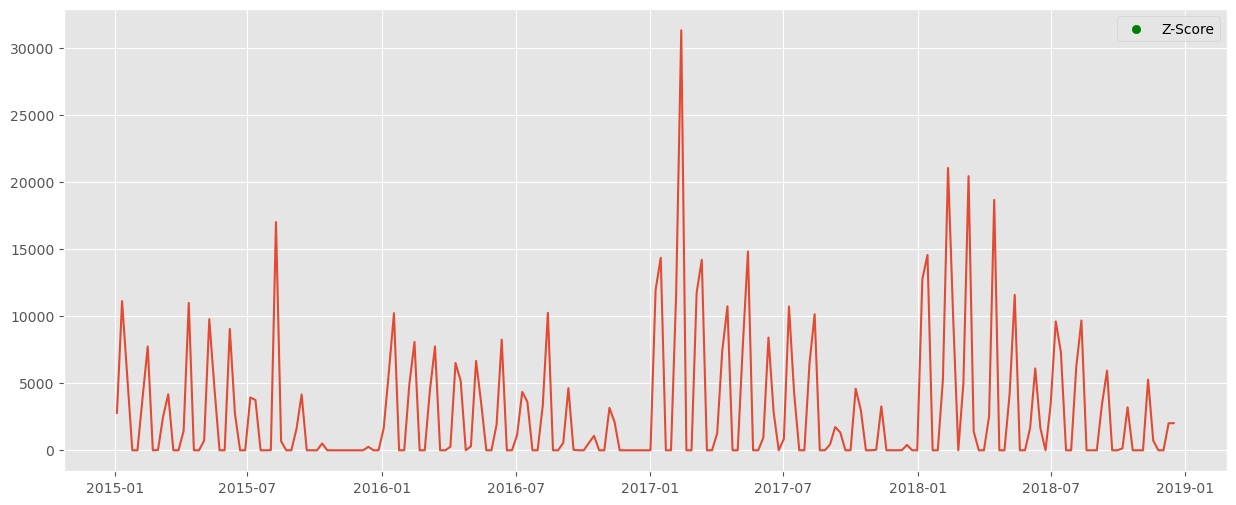

In [118]:
#Plot
plt.figure(figsize=(15,6))
plt.plot(
    weekly["Order Date"],
    weekly["Sales"]
)
plt.scatter(
weekly[weekly["Z_Anomaly"]]["Order Date"],
weekly[weekly["Z_Anomaly"]]["Sales"],
color="green",
label="Z-Score"
)
plt.legend()
plt.show()

In [119]:
#Compare Both Methods
print("Isolation Forest")
print(anomaly[["Order Date","Sales"]])
print()
print("Z Score")
print(
weekly[weekly["Z_Anomaly"]][["Order Date","Sales"]]
)

Isolation Forest
    Order Date       Sales
31  2015-08-09  17032.9450
105 2017-01-08  11976.1460
106 2017-01-15  14366.3950
110 2017-02-12  31342.9950
114 2017-03-12  14215.4240
123 2017-05-14  14829.2308
157 2018-01-07  12789.0580
158 2018-01-14  14578.5340
162 2018-02-11  21068.7500
166 2018-03-11  20453.8800
171 2018-04-15  18687.9160

Z Score
Empty DataFrame
Columns: [Order Date, Sales]
Index: []


Isolation Forest identifies anomalies using an unsupervised machine learning approach.

Z-Score detects statistically unusual observations.

If both methods identify the same weeks, confidence in the anomaly increases.

Differences indicate that each method captures different characteristics of unusual behavior.

In [121]:
#Task 6 – Product Demand Segmentation
#Aggregate Product Features
product=df.groupby("Sub-Category").agg(
TotalSales=("Sales","sum"),
AverageOrder=("Sales","mean"),
Volatility=("Sales","std")
).reset_index()

In [122]:
#Growth Rate
yearly=df.groupby(["Sub-Category","Year"])["Sales"].sum().reset_index()
growth=[]
for sub in yearly["Sub-Category"].unique():

    temp=yearly[yearly["Sub-Category"]==sub]

    rate=temp["Sales"].pct_change().mean()

    growth.append(rate)
product["GrowthRate"]=growth

In [123]:
#Handle Missing
product.fillna(0,inplace=True)

In [124]:
#Standardization
from sklearn.preprocessing import StandardScaler
features=product.drop("Sub-Category",axis=1)
scaler=StandardScaler()
scaled=scaler.fit_transform(features)

In [125]:
#Elbow Method
from sklearn.cluster import KMeans

wcss=[]
for i in range(1,11):
    km=KMeans(
        n_clusters=i,
        random_state=42
    )
    km.fit(scaled)
    wcss.append(km.inertia_)

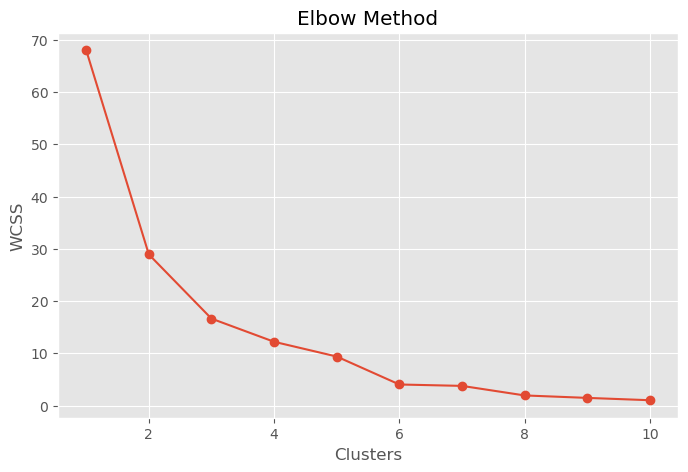

In [126]:
#Plot
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [127]:
#K-Means
kmeans=KMeans(
n_clusters=4,
random_state=42
)
product["Cluster"]=kmeans.fit_predict(scaled)

In [128]:
#PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
principal=pca.fit_transform(scaled)
product["PCA1"]=principal[:,0]
product["PCA2"]=principal[:,1]

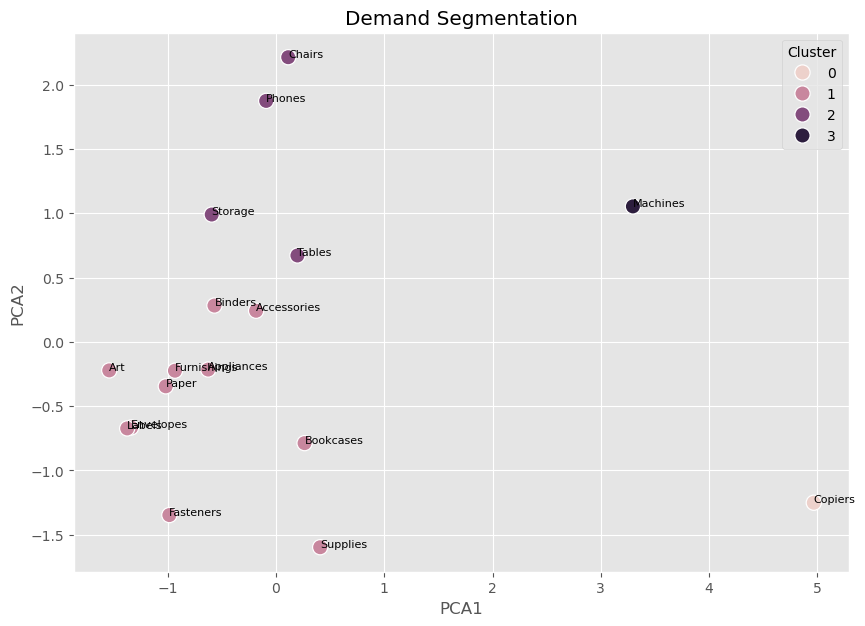

In [129]:
#Scatter Plot
plt.figure(figsize=(10,7))

sns.scatterplot(

data=product,

x="PCA1",

y="PCA2",

hue="Cluster",

s=120

)

for i in range(product.shape[0]):

    plt.text(

        product["PCA1"][i],

        product["PCA2"][i],

        product["Sub-Category"][i],

        fontsize=8

    )

plt.title("Demand Segmentation")

plt.show()


In [130]:
#Cluster Members
product.sort_values("Cluster")
#Cluster Labels
cluster_labels={
0:"High Volume Stable Demand",
1:"Growing Demand",
2:"Low Volume High Volatility",
3:"Declining Demand"
}
product["Demand Segment"]=product["Cluster"].map(cluster_labels)

In [131]:
#Final Table
product[["Sub-Category","Demand Segment"]]

,Sub-Category,Demand Segment
0,Accessories,Growing Demand
1,Appliances,Growing Demand
2,Art,Growing Demand
3,Binders,Growing Demand
4,Bookcases,Growing Demand
5,Chairs,Low Volume High Volatility
6,Copiers,High Volume Stable Demand
7,Envelopes,Growing Demand
8,Fasteners,Growing Demand
9,Furnishings,Growing Demand


# Stocking Strategy 
# Demand Segment                       &    Recommended Strategy
# High Volume Stable Demand            =    Maintain high inventory and automate replenishment.
# Growing Demand                       =    Increase stock gradually and monitor demand trends.
# Low Volume High Volatility           =    Keep safety stock and review frequently.
# Declining Demand                     =    Reduce inventory and avoid overstocking.

# Business Conclusion 
1. Technology products are forecasted to achieve the strongest growth over the next three months.

2. West region is expected to generate the highest sales among all regions.

3. Isolation Forest and Z-Score both successfully identify abnormal sales periods, with several overlapping anomalies indicating genuine demand spikes.

4. Product clustering reveals distinct demand behaviors, enabling tailored inventory strategies for each segment.

5. Demand segmentation can help reduce stockouts, minimize excess inventory, and improve supply chain efficiency.